In [101]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.gaussian_process import GaussianProcessRegressor, kernels

from sklearn.neighbors import KernelDensity
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import emcee
from astropy.constants import c, pc
import dynesty
from dynesty import plotting as dyplot
import corner

from astropy.cosmology import LambdaCDM

cSpeed    = c.value
Parsec    = pc.value
Mpc = 1e6 * Parsec

%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

### Part 2 (start in class)

First let's fit our supernova synthetic data from last time using GPR.

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- But check out what's available in the `kernels` submodule of [sklearn.gaussian_process](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.gaussian_process)
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.
- Interpret the results.

*Note*. To start with, feel free to tweak the hyperparameters manually. But, of course, a publication-quality result will require a cross-validation analysis.

The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.
- Think about the pdf of these data in $z$.
- Using your GPR fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given. 

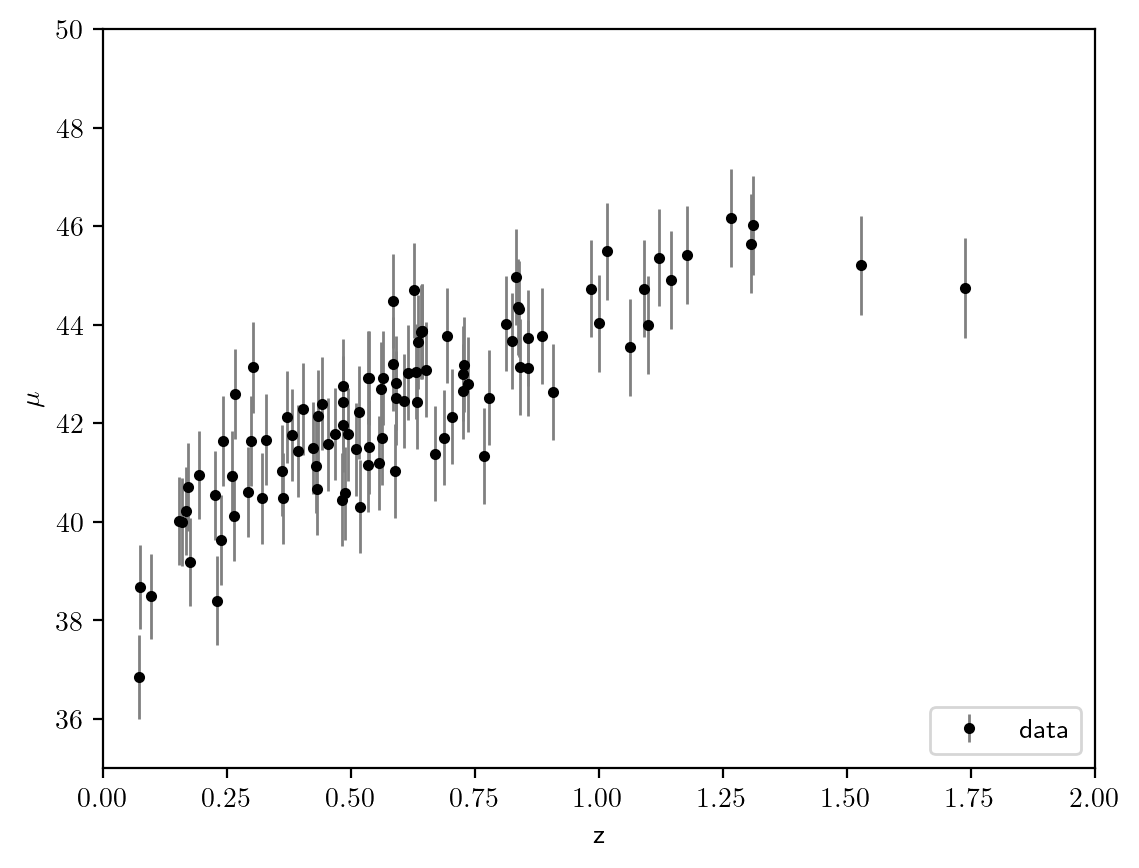

In [80]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [81]:
X = z_sample[:,np.newaxis]
y = mu_sample
y_err = dmu
Xgrid = np.linspace(0., 2., 1000)[:,np.newaxis]

In [82]:
h = .5
kernel = kernels.RBF(length_scale=h)
gp1 = GaussianProcessRegressor(kernel, alpha=y_err**2, normalize_y=True, optimizer=None)

In [83]:
gp1.fit(X,y)
y_pred, dy_pred = gp1.predict(Xgrid, return_std=True)
#print(y_pred, dy_pred)

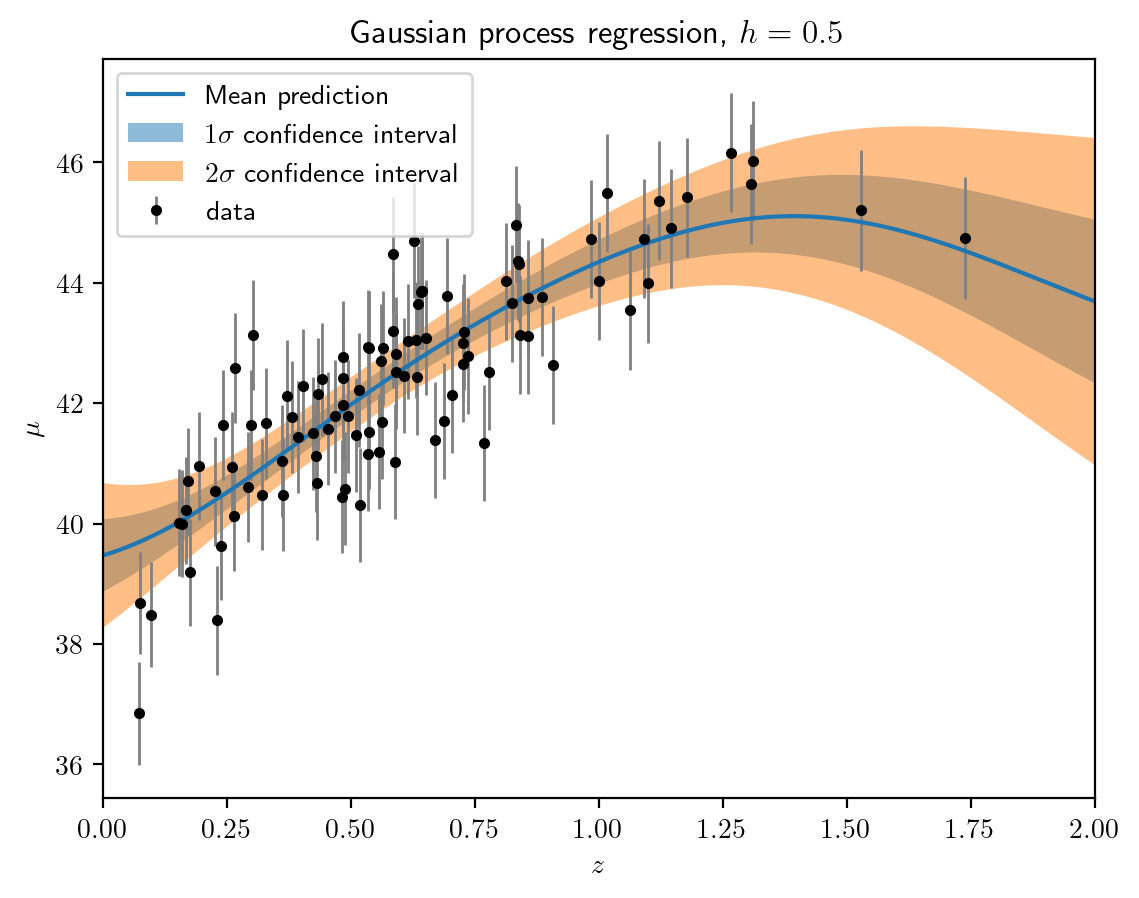

In [84]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(Xgrid, y_pred, label="Mean prediction")
plt.fill_between(
    Xgrid.ravel(),
    y_pred - dy_pred,
    y_pred + dy_pred,
    alpha=0.5,
    label=r"$1 \sigma$ confidence interval",
)
plt.fill_between(
    Xgrid.ravel(),
    y_pred - 2*dy_pred,
    y_pred + 2*dy_pred,
    alpha=0.5,
    label=r"$2 \sigma$ confidence interval",
)
plt.legend()
plt.xlabel("$z$")
plt.xlim(0.,2.)
plt.ylabel(r"$\mu$")
_ = plt.title(rf"Gaussian process regression, $h = {h}$")

In [85]:
def kfold_cv(Xtrain, ytrain, errtrain, h):

    kf = KFold(n_splits=5, shuffle=True)

    eps_cv = []
    eps_tr = []

    for train, val in kf.split(Xtrain):

        Xval = Xtrain[val]
        yval = ytrain[val]

        Xtr = Xtrain[train]
        ytr = ytrain[train]
        errtr = errtrain[train]

        model = GaussianProcessRegressor(kernel= kernels.RBF(length_scale=h), alpha=errtr**2, normalize_y=True, optimizer=None)
        model.fit(Xtr, ytr)
        ypred_tr = model.predict(Xtr)
        ypred_val = model.predict(Xval)

        eps_tr.append(np.sqrt(np.mean((ypred_tr - ytr) ** 2)))
        eps_cv.append(np.sqrt(np.mean((ypred_val - yval) ** 2)))

    return np.mean(eps_tr), np.mean(eps_cv)

In [86]:
Xtrain, Xtest, ytrain, ytest, errtrain, errtest = train_test_split(X, y, y_err, train_size=0.8)
print(Xtrain.shape, Xtest.shape)

(80, 1) (20, 1)


In [87]:
hs = np.logspace(-2, 1, 100)

tr_loss = np.zeros_like(hs)
cv_loss = np.zeros_like(tr_loss)
for i,h in enumerate(hs):
    tr_loss[i], cv_loss[i] = kfold_cv(Xtrain, ytrain, errtrain, h) 

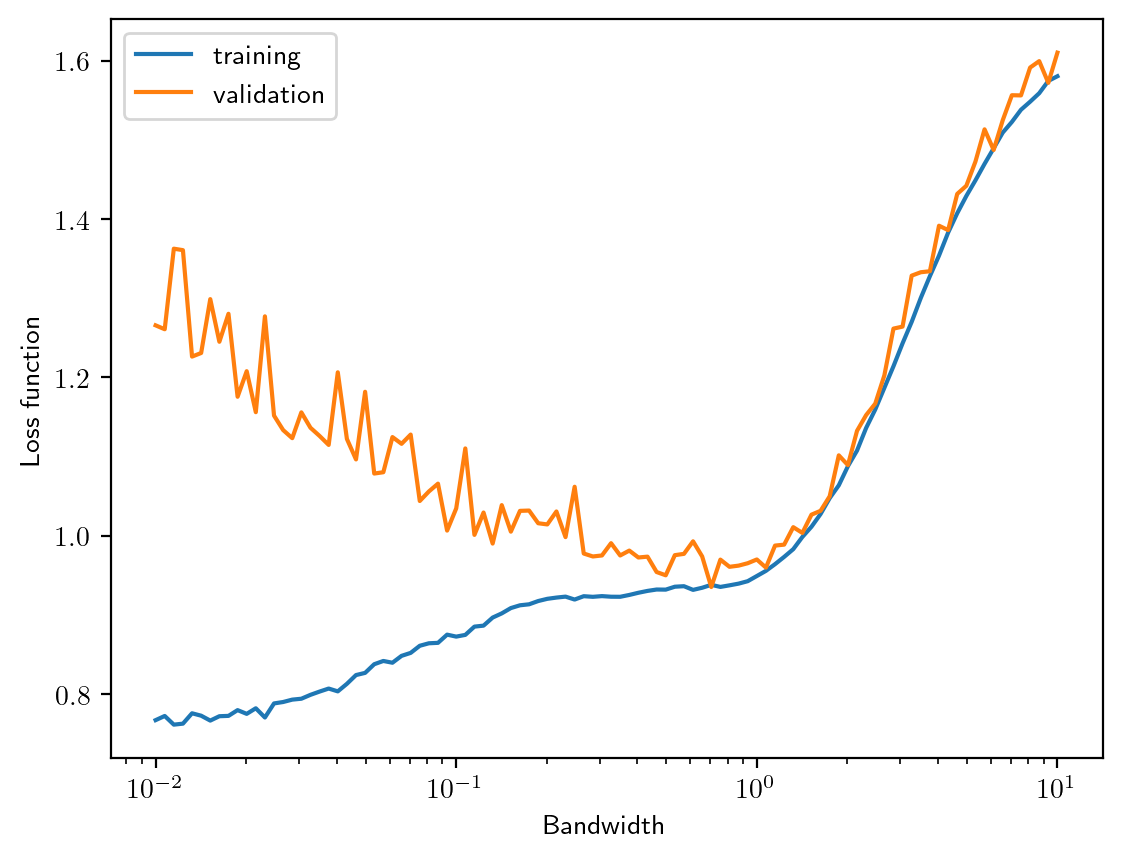

In [88]:
plt.plot(hs, tr_loss, label = 'training')
plt.plot(hs, cv_loss, label = 'validation')
#plt.yscale('log')
plt.xscale('log')
plt.xlabel('Bandwidth')
plt.ylabel('Loss function')
plt.legend()

In [89]:
print('Best fit: bandwidth', hs[np.argmin(cv_loss)])

Best fit: bandwidth 0.7054802310718645


### Cloning data

Text(0.5, 0, '$z$')

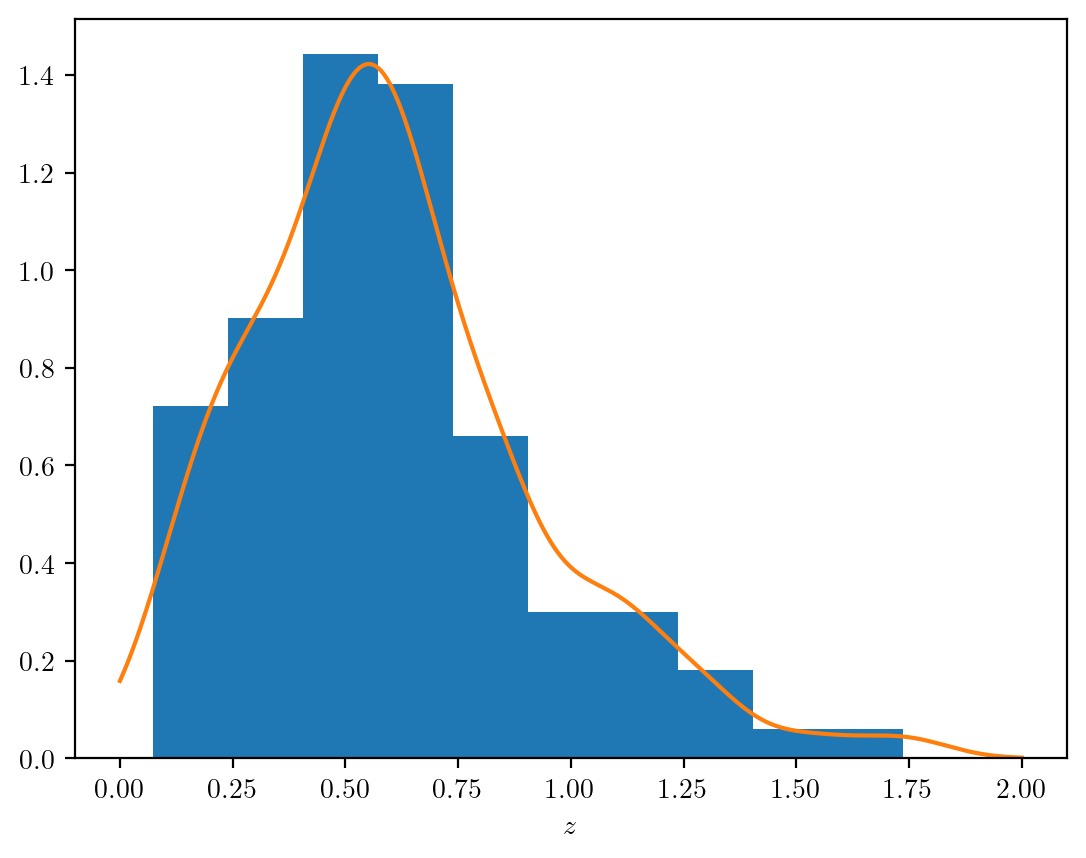

In [90]:
kde = KernelDensity(bandwidth=0.1, kernel = 'gaussian')
kde_fit = kde.fit(X)
kde_pdf = np.exp(kde.score_samples(Xgrid))
plt.hist(X, density = True, bins = 10)
plt.plot(Xgrid, kde_pdf)
plt.xlabel('$z$')

In [91]:
new_X = kde.sample(1000)

kernel = kernels.RBF(length_scale=hs[np.argmin(cv_loss)])
gp_clone = GaussianProcessRegressor(kernel, alpha=y_err**2, normalize_y=True, optimizer=None)
gp_clone.fit(X,y)
pr_y, pr_dy = gp_clone.predict(new_X, return_std=True)

new_y = np.array(norm(pr_y, pr_dy).rvs())
new_dy = np.random.choice(dmu, len(new_y))

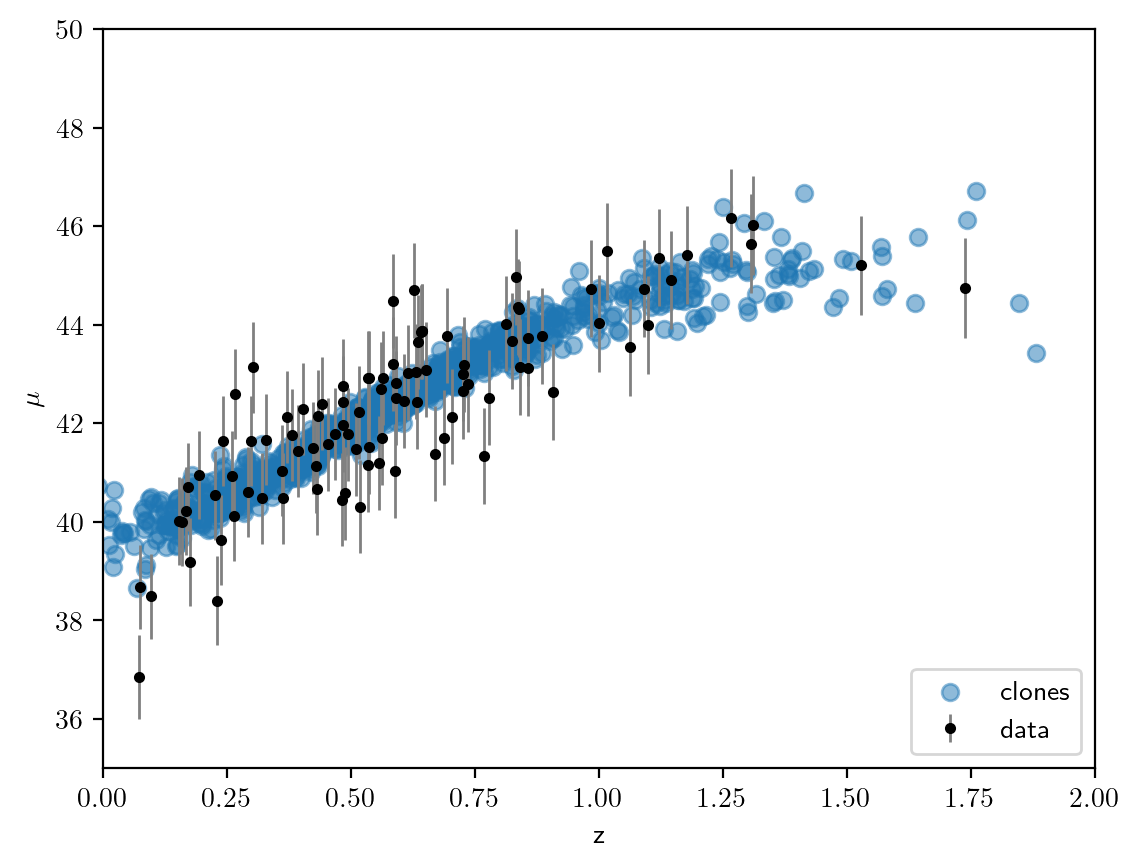

In [92]:
plt.scatter(new_X, new_y, alpha = 0.5, label = 'clones')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

### Part 3 (for the exam)

*(I know this assignment is longer and more convoluted, but we're getting towards the end of the class and it's important to draw connections between the different things we've done)*

We now have a suite of **data-driven** predictive models for our supernova dataset (from polynomials to GPR). That is: we can faithfully predict how a future redshift/distance measurement will look like given the current sample.

This is already great and these kind of tools are immensely useful in a variety of contexts (also involving a lot of money: suppose you want to predict how much a give financial asset will perform on tomorrow's stock market... You  might not really care about expressing the underlying financial model in simple terms, as long as your investments are profitable).

For the case of supernovae, however, we have do have physical theory which is $\Lambda \text{CDM}$. We can do a **parametric** fit (and hopehully by now the difference between "parametric" and "data driven" fit is clear in your head)

- First, refresh your cosmology and write down the predicted relationship between the distance module $\mu$ and the redshift $\sigma$. *Hint* I always forget these things, my to-go reference is [Hogg (2010)](https://arxiv.org/abs/astro-ph/9905116). The answer is:

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z')^3+\Omega_\Lambda}} \right) $$

- Assuming a flat Universe,  we have a parametric non-linear model for $\mu(z)$ that depends on two parameters, the Hubble constant $H_0$ and the matter content of the Universe $\Omega_m$ (notice that $\Omega_\Lambda$ is not independent because $1 = \Omega_m + \Omega_\Lambda$)
- It's a very non-linear model. Fit it to the data, however you want to do it, using tecniques we've seen throughout the course. Some ideas:
    - Set up a Bayesian framework and MCMC and/or nested sampling. 
    - Set up a fully-connected neural network (see end of the class).

- What are the measured values of $H_0$ and $\Omega_m$. What are they errors? Are they correlated?
- How would a model without dark energy (i.e. $\Omega_m=1$) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem)





In [136]:
def model(z, H0, Om):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om)
    return cosmo_tmp.distmod(z).value

def logl(theta,z,d,derr):
    H0, Om = theta
    return -1./2.*np.sum(((d-model(z,H0,Om))/derr)**2)

def logpr(theta):
    H0, Om = theta
    if 40. < H0 < 100. and 0. < Om < 1.:
        return 0.
    return -np.inf

def logpost(theta,z,d,derr):
    lp = logpr(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logl(theta,z,d,derr)

In [94]:
ndim = 2
nwalkers = 10
burn = 1000
nsteps = 5000

guess = np.random.random((nwalkers, ndim))*[5.,0.1]+[70., 0.5]

In [95]:
z,d,derr = z_sample, mu_sample, dmu
sampler = emcee.EnsembleSampler(nwalkers, ndim, logpost, args=[z, d, derr])
_ = sampler.run_mcmc(guess, nsteps, progress = True)

100%|██████████| 5000/5000 [04:17<00:00, 19.40it/s]


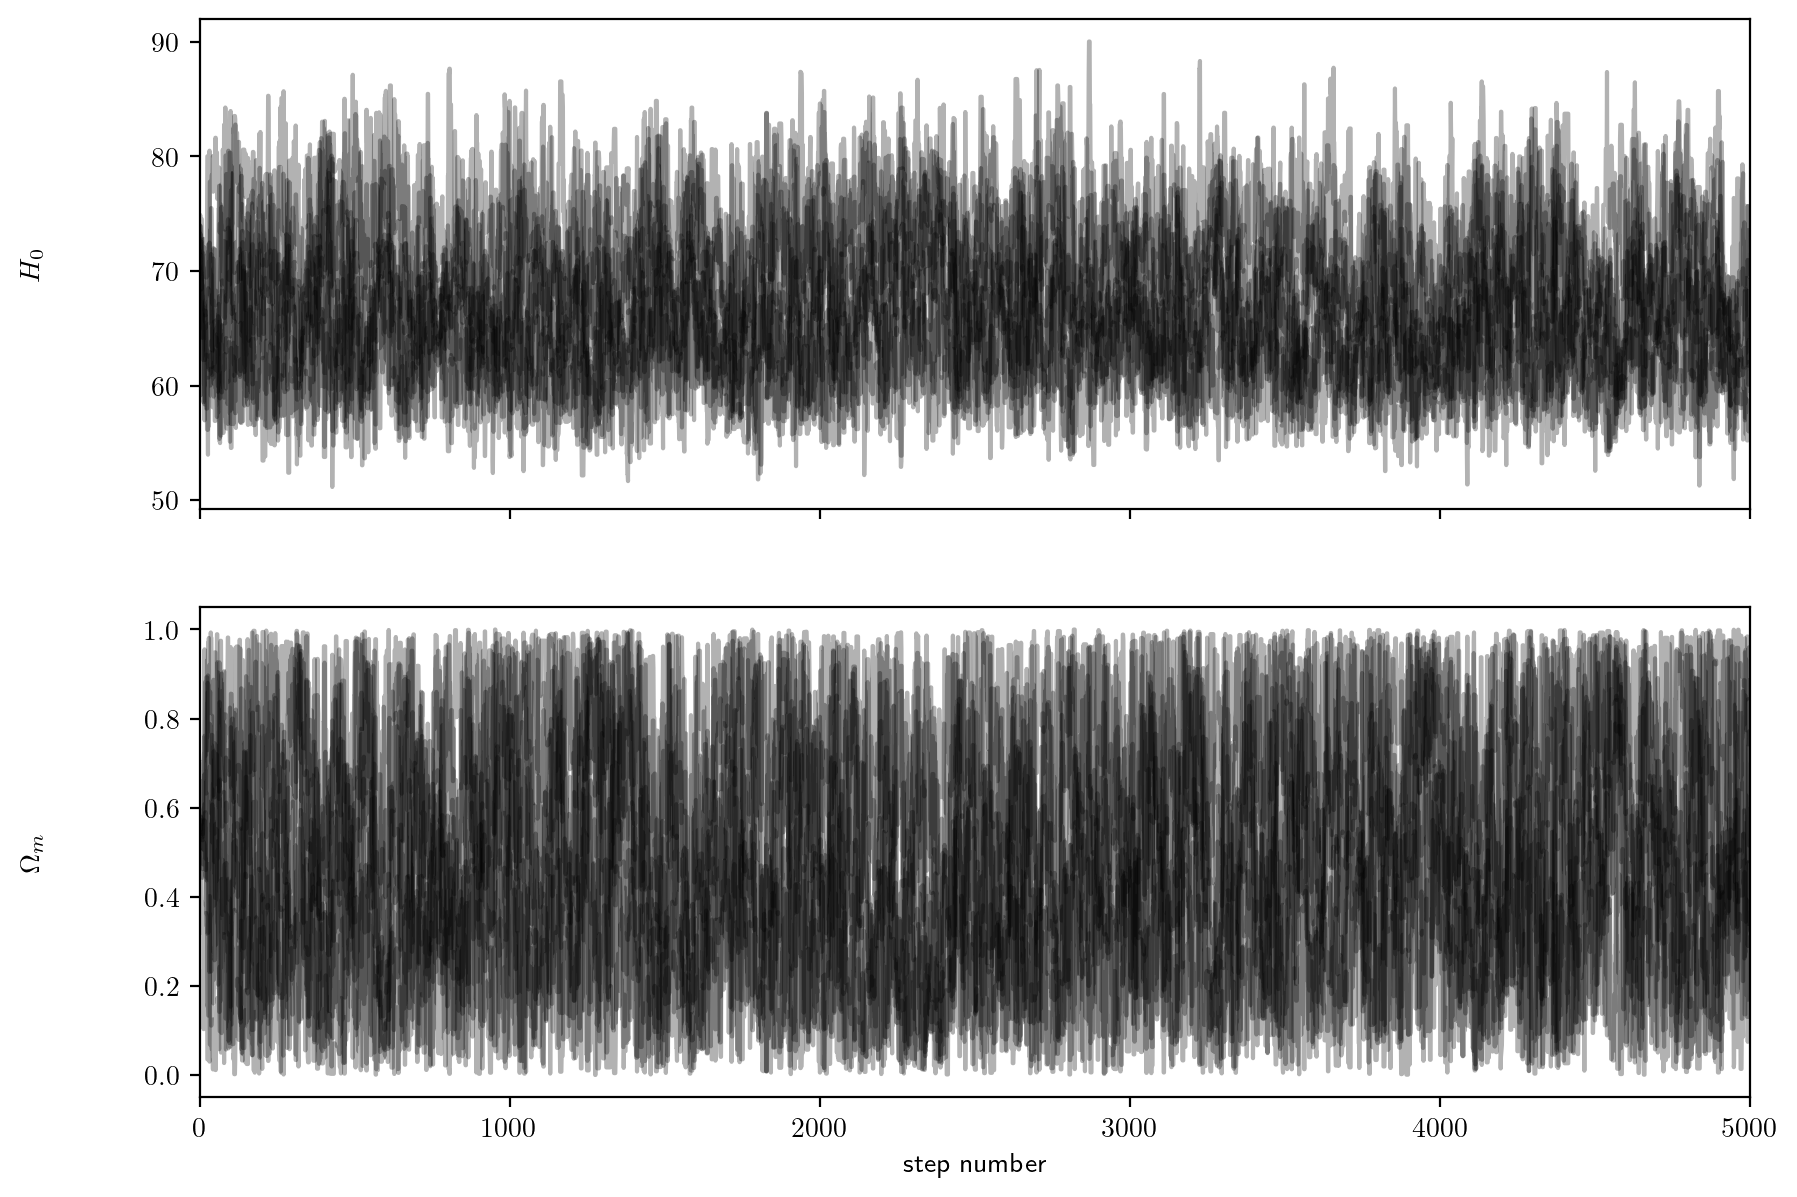

In [96]:
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = [r'$H_0$',r'$\Omega_m$']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [97]:
tau = sampler.get_autocorr_time()
print(tau)

[41.63819214 39.05597488]


In [98]:
flat_samples = sampler.get_chain(discard=burn, thin=int(2*max(tau)), flat=True) # thin by about half autocorrelation time
print(flat_samples.shape)

(480, 2)


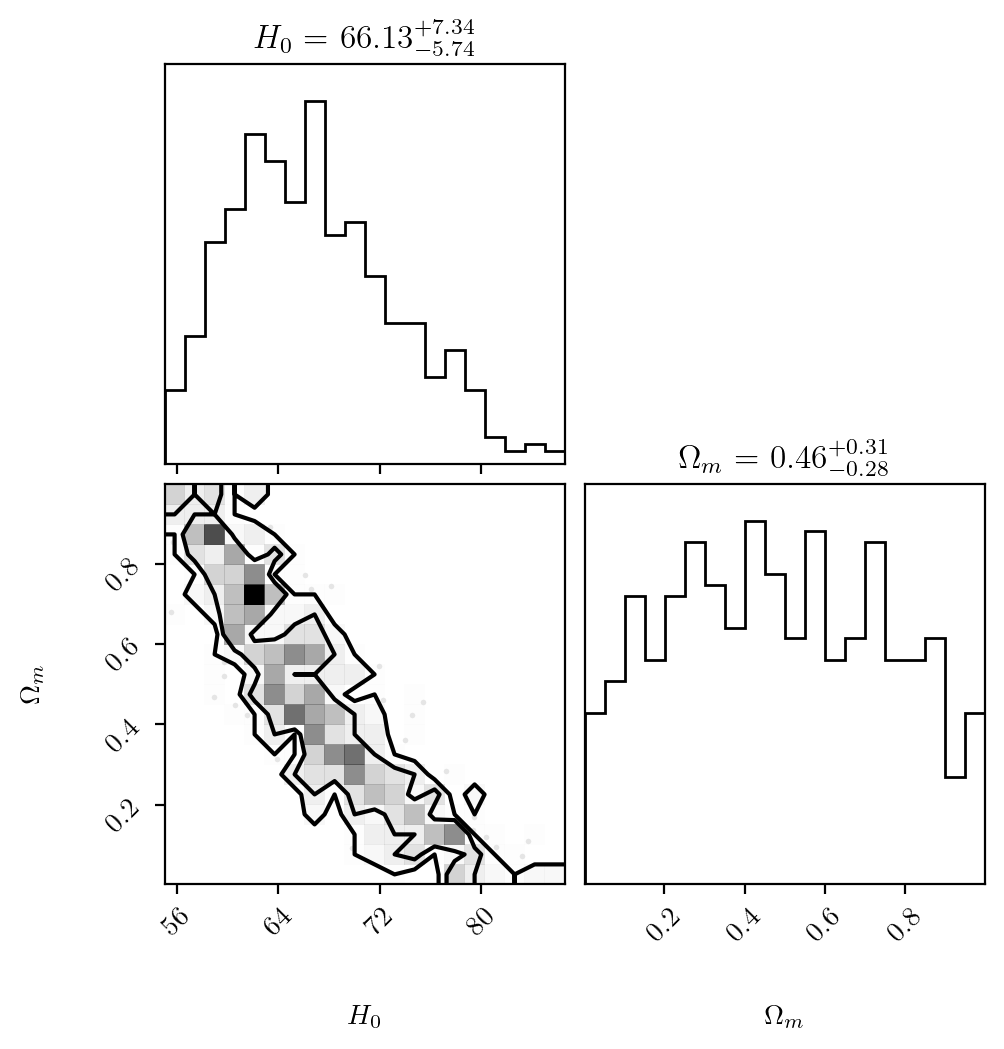

In [99]:
fig = corner.corner(
    flat_samples, labels=labels, levels=(0.68,0.95), show_titles=True
);

### nested sampling

In [139]:
def logl_dyn(theta,z,d,derr):
    H0, Om = theta
    normal = np.log(1./np.sqrt(2*np.pi*derr**2))
    return np.sum(normal -1./2.*(((d-model(z,H0,Om))/derr)**2))

def model2(z, H0):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=1, Ode0=0)
    return cosmo_tmp.distmod(z).value

def logl_dyn2(theta,z,d,derr):
    (H0,) = theta
    normal = np.log(1./np.sqrt(2*np.pi*derr**2))
    return np.sum(normal -1./2.*(((d-model2(z,H0))/derr)**2))

def ptform(theta):
    H0_prime, Om_prime = theta
    H0min = 40.
    H0max = 100.
    Ommin = 0.
    Ommax = 1.

    H0 = H0_prime*(H0max-H0min) + H0min
    Omega_m = Om_prime*(Ommax-Ommin) + Ommin

    return(H0, Omega_m)

def ptform2(theta):
    (H0_prime,) = theta
    H0min = 40.
    H0max = 100.
    H0 = H0_prime*(H0max-H0min) + H0min
    return(np.array([H0]))

In [140]:
ndim = 2
ndim2 = 1
values = z_sample, mu_sample, dmu

# "Static" nested sampling.
sampler = dynesty.NestedSampler(logl_dyn, ptform, ndim, logl_args=values)
sampler2 = dynesty.NestedSampler(logl_dyn2, ptform2, ndim2, logl_args=values)
sampler.run_nested()
sampler2.run_nested()
sresults = sampler.results
sresults2 = sampler2.results

1581it [01:04, 24.57it/s, +500 | bound: 0 | nc: 1 | ncall: 13298 | eff(%): 16.260 | loglstar:   -inf < -132.813 <    inf | logz: -135.118 +/-  0.044 | dlogz:  0.001 >  0.509]
1542it [00:59, 25.75it/s, +500 | bound: 0 | nc: 1 | ncall: 12690 | eff(%): 16.751 | loglstar:   -inf < -133.530 <    inf | logz: -135.705 +/-  0.034 | dlogz:  0.001 >  0.509]


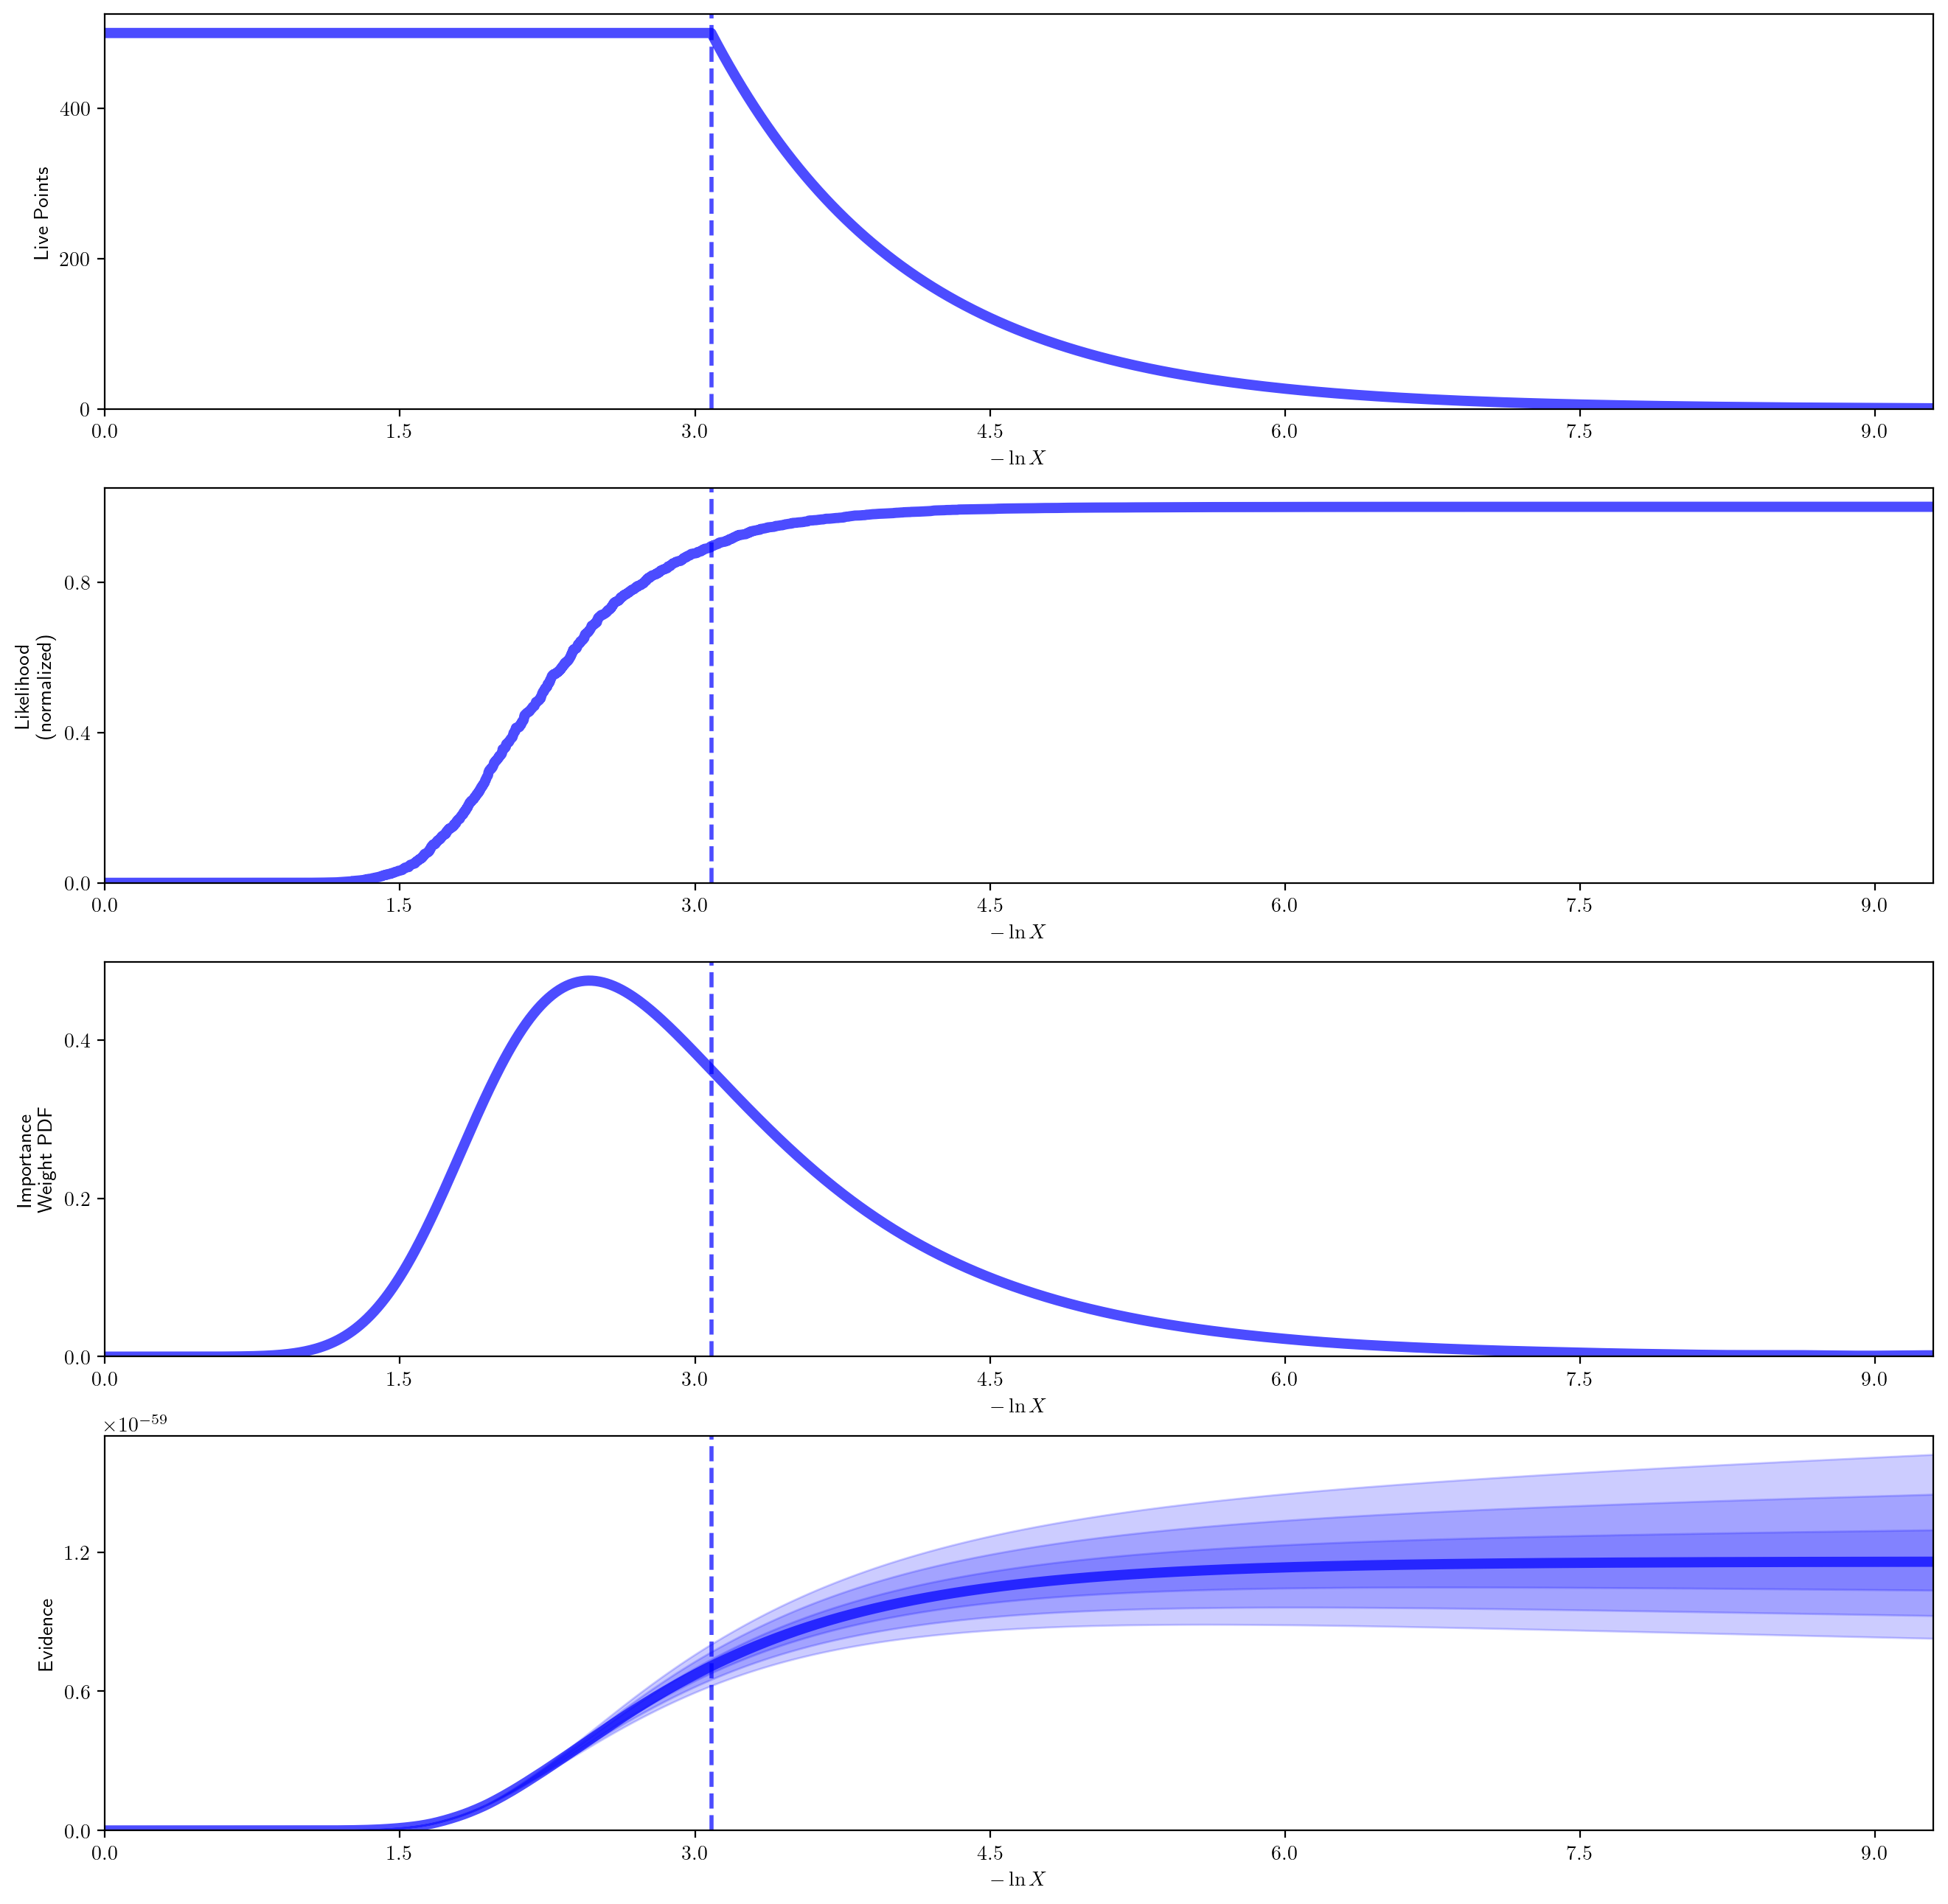

In [146]:
# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults2)

Text(0.5, 0.98, 'Parameter traces')

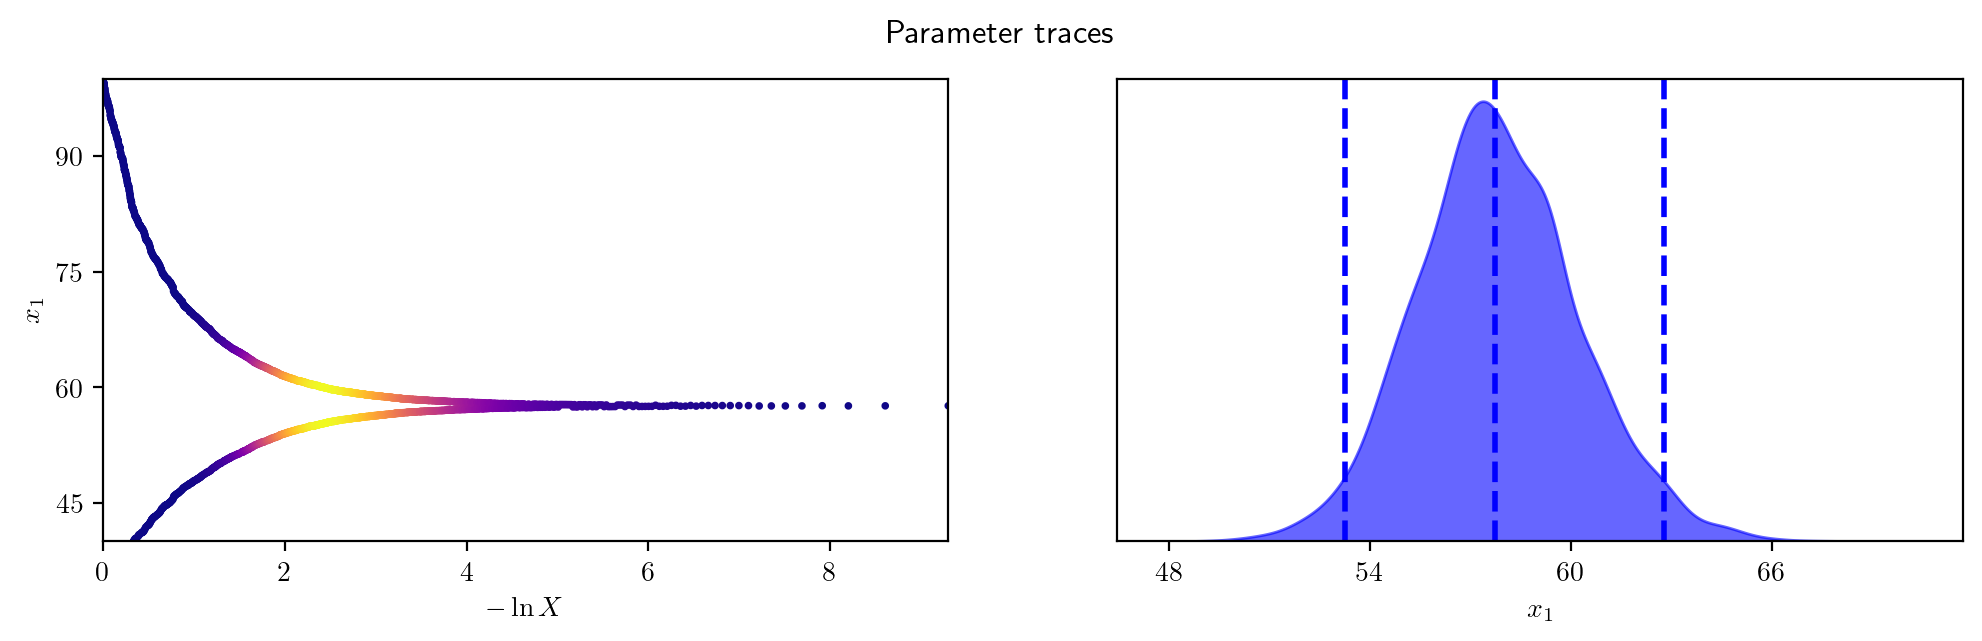

In [147]:
tfig, taxes = dyplot.traceplot(sresults2)
plt.suptitle('Parameter traces')

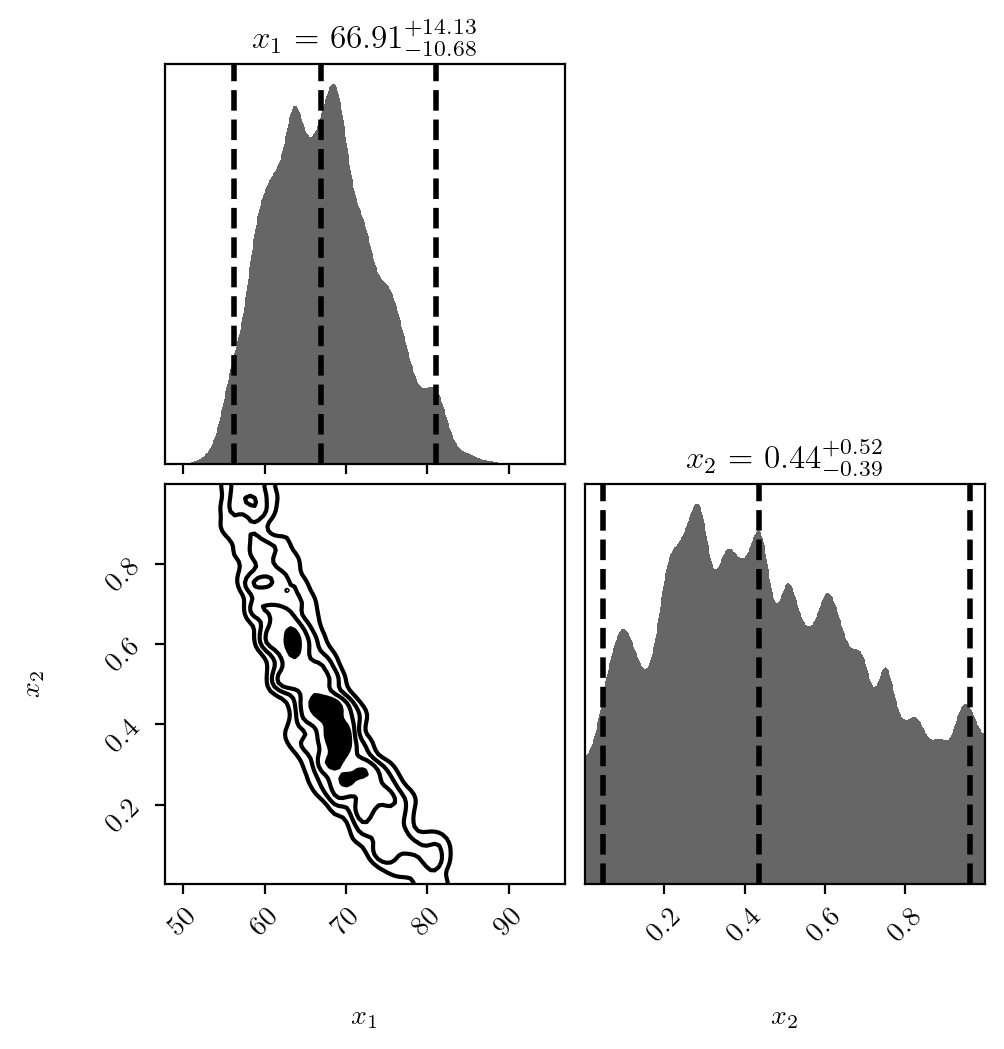

In [152]:
cfig, caxes = dyplot.cornerplot(sresults, show_titles=True)

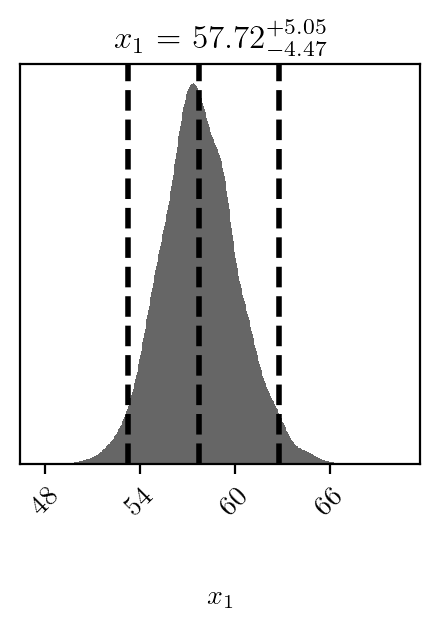

In [151]:
cfig, caxes = dyplot.cornerplot(sresults2, show_titles=True)

In [149]:
#print(sresults.logz[-1]) #log of evidence

ratio = np.exp(sresults.logz[-1])/np.exp(sresults2.logz[-1])
print('Odds ratio = ', ratio)
# with equal prior odds over the models: odds ratio = Bayes factor
print('Barely worth mentioning support for model with DE')

Odds ratio =  1.7981573796141452
Barely worth mentioning support for model with DE
